<a href="https://colab.research.google.com/github/mandavi-singh/smart-parking-pricing/blob/main/Parking_Pricing_Models_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd


df = pd.read_csv('/content/dataset.csv')

df.head()


,ID,SystemCodeNumber,Capacity,Latitude,Longitude,Occupancy,VehicleType,TrafficConditionNearby,QueueLength,IsSpecialDay,LastUpdatedDate,LastUpdatedTime
0,0,BHMBCCMKT01,577,26.144536,91.736172,61,car,low,1,0,04-10-2016,07:59:00
1,1,BHMBCCMKT01,577,26.144536,91.736172,64,car,low,1,0,04-10-2016,08:25:00
2,2,BHMBCCMKT01,577,26.144536,91.736172,80,car,low,2,0,04-10-2016,08:59:00
3,3,BHMBCCMKT01,577,26.144536,91.736172,107,car,low,2,0,04-10-2016,09:32:00
4,4,BHMBCCMKT01,577,26.144536,91.736172,150,bike,low,2,0,04-10-2016,09:59:00


In [2]:
print(df.shape)

(18368, 12)


In [3]:
print(df.columns)

Index(['ID', 'SystemCodeNumber', 'Capacity', 'Latitude', 'Longitude',
       'Occupancy', 'VehicleType', 'TrafficConditionNearby', 'QueueLength',
       'IsSpecialDay', 'LastUpdatedDate', 'LastUpdatedTime'],
      dtype='object')


In [4]:
df['Timestamp'] = pd.to_datetime(df['LastUpdatedDate'] + ' ' + df['LastUpdatedTime'], format="%d-%m-%Y %H:%M:%S")

df = df.rename(columns={'SystemCodeNumber': 'LotID'})


df_model1 = df[['LotID', 'Timestamp', 'Occupancy', 'Capacity']]


df_model1 = df_model1.sort_values('Timestamp').reset_index(drop=True)


df_model1.to_csv("parking_stream.csv", index=False)


In [5]:
!pip install pathway bokeh panel --quiet


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.4/149.4 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.7/69.7 MB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.6/77.6 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 777.6/777.6 kB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.2/139.2 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.3/135.3 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.6/244.6 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.4/318.4 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 985.8/985.8 kB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [6]:
import pathway as pw
import panel as pn
import bokeh.plotting
import datetime

pn.extension()


In [7]:
df = pd.read_csv('/content/dataset.csv')


df['Timestamp'] = pd.to_datetime(df['LastUpdatedDate'] + ' ' + df['LastUpdatedTime'],
                                 format="%d-%m-%Y %H:%M:%S")


df = df.rename(columns={'SystemCodeNumber': 'LotID'})

df_model1 = df[['LotID', 'Timestamp', 'Occupancy', 'Capacity']]


df_model1 = df_model1.sort_values('Timestamp').reset_index(drop=True)


df_model1.to_csv("parking_stream.csv", index=False)


df_model1.head()


,LotID,Timestamp,Occupancy,Capacity
0,BHMBCCMKT01,2016-10-04 07:59:00,61,577
1,BHMNCPHST01,2016-10-04 07:59:00,237,1200
2,BHMMBMMBX01,2016-10-04 07:59:00,264,687
3,BHMNCPNST01,2016-10-04 07:59:00,249,485
4,Shopping,2016-10-04 07:59:00,614,1920


In [8]:
class ParkingSchema(pw.Schema):
    LotID: str
    Timestamp: str
    Occupancy: int
    Capacity: int

# Simulate real-time stream using Pathway
data = pw.demo.replay_csv("parking_stream.csv", schema=ParkingSchema, input_rate=100)


In [9]:
fmt = "%Y-%m-%d %H:%M:%S"
data_with_time = data.with_columns(
    t = data.Timestamp.dt.strptime(fmt)
)


In [10]:
base_price = 10
alpha = 10

price_model = data_with_time.with_columns(
    occ_ratio = data_with_time.Occupancy / data_with_time.Capacity,
    raw_price = base_price + alpha * (data_with_time.Occupancy / data_with_time.Capacity)
)


price_model = price_model.with_columns(
    Price = pw.if_else(
        price_model.raw_price < 5,
        5,
        pw.if_else(price_model.raw_price > 20, 20, price_model.raw_price)
    )
)


In [11]:
def baseline_linear_price(prev_price, occupancy, capacity, alpha=1.0):
    occ_rate = occupancy / capacity
    next_price = prev_price + alpha * occ_rate
    return next_price


In [12]:
price_t = 100
occupancy = 30
capacity = 50
predicted_price = baseline_linear_price(price_t, occupancy, capacity, alpha=2.5)
print(f"Next Price: ₹{predicted_price:.2f}")


Next Price: ₹101.50


In [13]:
from bokeh.plotting import figure, show, output_notebook
from bokeh.models import ColumnDataSource
import numpy as np

# Show Bokeh output in notebook
output_notebook()

# Parameters for Model 1
alpha = 2.5
capacity = 50
prev_price = 100

# Generate occupancy values
occupancy = np.linspace(0, capacity, 100)
occupancy_rate = occupancy / capacity
next_price = prev_price + alpha * occupancy_rate

# Prepare data for Bokeh
source = ColumnDataSource(data=dict(
    occupancy=occupancy,
    price=next_price
))

# Create the Bokeh plot
p = figure(
    title="Model 1: Price vs Occupancy",
    x_axis_label="Occupancy (vehicles)",
    y_axis_label="Predicted Price (₹)",
    width=700,
    height=400
)

# Plot line and points
p.line('occupancy', 'price', source=source, line_width=2, color="blue", legend_label="Price")
p.circle('occupancy', 'price', source=source, size=5, color="red", legend_label="Price Points")

# Add legend
p.legend.location = "top_left"
p.legend.click_policy = "hide"

# Show the plot
show(p)


In [14]:
import pandas as pd
import numpy as np
from bokeh.plotting import figure, show
from bokeh.io import output_notebook
output_notebook()
df = pd.read_csv('/content/dataset.csv')

base_price = 50

alpha = 1.0
beta = 0.5
gamma = 0.3
delta = 2.0
epsilon = 1.5
lambda_coeff = 0.8

vehicle_type_weights = {
    'Car': 1.0,
    'Bus': 2.0,
    'Truck': 2.5,
    'Bike': 0.8,
    'Auto': 1.2
}


# Vehicle type mapping
vehicle_type_weights = {'car': 1.0, 'truck': 1.5, 'bike': 0.8, 'bus': 1.2}
df['VehicleTypeWeight'] = df['VehicleType'].map(vehicle_type_weights)

# Boolean column conversion
df['IsSpecialDay'] = df['IsSpecialDay'].astype(int)

# Traffic level conversion (fix for your error)
traffic_mapping = {'low': 0.2, 'medium': 0.5, 'high': 0.8}
df['TrafficConditionNearby'] = df['TrafficConditionNearby'].map(traffic_mapping)

df['Capacity'] = df['Capacity'].replace(0, np.nan)
df.dropna(subset=['Capacity'], inplace=True)


df['OccupancyRate'] = df['Occupancy'] / df['Capacity']
df['Demand'] = (
    alpha * df['OccupancyRate'] +
    beta * df['QueueLength'] -
    gamma * df['TrafficConditionNearby'] +
    delta * df['IsSpecialDay'] +
    epsilon * df['VehicleTypeWeight']
)

# Normalize Demand
df['NormalizedDemand'] = (df['Demand'] - df['Demand'].min()) / (df['Demand'].max() - df['Demand'].min())


df['DynamicPrice'] = base_price * (1 + lambda_coeff * df['NormalizedDemand'])
df['DynamicPrice'] = df['DynamicPrice'].clip(lower=base_price * 0.5, upper=base_price * 2)

# --- BOKEH Visualization ---
p = figure(title="Dynamic Price vs Normalized Demand (Model 2)",
           x_axis_label='Normalized Demand',
           y_axis_label='Dynamic Price',
           width=700, height=400)

p.circle(df['NormalizedDemand'], df['DynamicPrice'],
         size=8, color="green", alpha=0.6, legend_label="Pricing Points")

p.legend.location = "top_left"
p.title.text_font_size = "14pt"

show(p)


In [15]:
df['BasePrice'] = 30 + df['VehicleTypeWeight'] * 10


In [17]:
df['DynamicPrice'] = df['BasePrice'] * (1 + lambda_coeff * df['NormalizedDemand'])
df['DynamicPrice'] = df['DynamicPrice'].clip(lower=df['BasePrice'] * 0.5, upper=df['BasePrice'] * 2)

In [18]:
df['NormalizedDemand'] = (df['Demand'] - df['Demand'].min()) / (df['Demand'].max() - df['Demand'].min())


lambda_coeff = 0.5

#Calculate Dynamic Price
df['DynamicPrice'] = df['BasePrice'] * (1 + lambda_coeff * df['NormalizedDemand'])

df['DynamicPrice'] = df['DynamicPrice'].clip(lower=df['BasePrice'] * 0.5, upper=df['BasePrice'] * 2)


In [19]:
df['DynamicPrice'] = df['DynamicPrice'].round(2)


In [20]:
import pandas as pd
import numpy as np
from bokeh.plotting import figure, show, output_notebook
from bokeh.models import ColumnDataSource
from bokeh.transform import linear_cmap


output_notebook()


np.random.seed(42)
df = pd.DataFrame({
    'Capacity': np.random.randint(10, 100, 50),
    'Occupancy': np.random.randint(1, 100, 50),
    'QueueLength': np.random.randint(0, 10, 50),
    'Traffic': np.random.rand(50),
    'IsSpecialDay': np.random.randint(0, 2, 50),
    'VehicleTypeWeight': np.random.choice([1.0, 1.2, 1.5], 50)
})

alpha, beta, gamma, delta, epsilon = 1.0, 0.5, 0.8, 2.0, 3.0

# Calculate demand
df['Demand'] = (alpha * df['Occupancy'] / df['Capacity'] +
                beta * df['QueueLength'] -
                gamma * df['Traffic'] +
                delta * df['IsSpecialDay'] +
                epsilon * df['VehicleTypeWeight'])

# Normalize demand
df['NormalizedDemand'] = (df['Demand'] - df['Demand'].min()) / (df['Demand'].max() - df['Demand'].min())

# Base price and Dynamic price
df['BasePrice'] = 30 + df['VehicleTypeWeight'] * 10
lambda_coeff = 0.5
df['DynamicPrice'] = df['BasePrice'] * (1 + lambda_coeff * df['NormalizedDemand'])
df['DynamicPrice'] = df['DynamicPrice'].clip(lower=df['BasePrice'] * 0.5, upper=df['BasePrice'] * 2).round(2)

# Bokeh Plot
source = ColumnDataSource(df)
p = figure(title="Model 2: Dynamic Price vs Normalized Demand",
           x_axis_label="Normalized Demand", y_axis_label="Dynamic Price", width=700, height=400)

p.circle('NormalizedDemand', 'DynamicPrice', size=10, source=source,
         color=linear_cmap('VehicleTypeWeight', 'Viridis256',
                           df['VehicleTypeWeight'].min(), df['VehicleTypeWeight'].max()),
         fill_alpha=0.8)

show(p)


In [21]:
from bokeh.io import output_notebook
output_notebook()


In [22]:
import pandas as pd
import numpy as np
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource
from bokeh.transform import linear_cmap
from bokeh.io import output_notebook, output_file


output_file("dynamic_price_plot.html")

df = pd.DataFrame({
    'Capacity': [50]*10,
    'Occupancy': np.random.randint(10, 50, 10),
    'QueueLength': np.random.randint(1, 10, 10),
    'Traffic': np.random.rand(10),
    'IsSpecialDay': np.random.randint(0, 2, 10),
    'VehicleTypeWeight': np.random.choice([1.0, 1.2, 1.5], 10)
})

# Demand Calculation
alpha, beta, gamma, delta, epsilon = 1.0, 0.5, 0.8, 2.0, 3.0
df['Demand'] = (alpha * df['Occupancy'] / df['Capacity'] +
                beta * df['QueueLength'] -
                gamma * df['Traffic'] +
                delta * df['IsSpecialDay'] +
                epsilon * df['VehicleTypeWeight'])

df['NormalizedDemand'] = (df['Demand'] - df['Demand'].min()) / (df['Demand'].max() - df['Demand'].min())
df['BasePrice'] = 30 + df['VehicleTypeWeight'] * 10
lambda_coeff = 0.5
df['DynamicPrice'] = df['BasePrice'] * (1 + lambda_coeff * df['NormalizedDemand'])
df['DynamicPrice'] = df['DynamicPrice'].clip(lower=df['BasePrice'] * 0.5, upper=df['BasePrice'] * 2).round(2)

# Plot
source = ColumnDataSource(df)
p = figure(title="Dynamic Price vs Normalized Demand", x_axis_label="Normalized Demand", y_axis_label="Dynamic Price")
p.circle('NormalizedDemand', 'DynamicPrice', size=10, source=source,
         color=linear_cmap('VehicleTypeWeight', 'Viridis256',
                           df['VehicleTypeWeight'].min(), df['VehicleTypeWeight'].max()),
         fill_alpha=0.8)

show(p)


In [23]:
import pandas as pd
import numpy as np
from bokeh.plotting import figure, show
from bokeh.io import output_notebook
from bokeh.models import ColumnDataSource

output_notebook()


np.random.seed(0)
n = 100
df = pd.DataFrame({
    'Occupancy': np.random.randint(0, 100, size=n),
    'Capacity': np.random.randint(50, 100, size=n),
    'QueueLength': np.random.randint(0, 20, size=n),
    'TrafficConditionNearby': np.random.randint(1, 5, size=n),
    'IsSpecialDay': np.random.randint(0, 2, size=n),
    'VehicleType': np.random.choice(['Car', 'Truck', 'Bike'], size=n),
    'BasePrice': np.random.uniform(50, 150, size=n)
})

# Vehicle Type weights
vehicle_weights = {'Car': 1.0, 'Truck': 1.5, 'Bike': 0.8}
df['VehicleTypeWeight'] = df['VehicleType'].map(vehicle_weights)

# Normalize components
df['OccupancyRate'] = df['Occupancy'] / df['Capacity']
df['TrafficLevel'] = df['TrafficConditionNearby']

# Model 2: Demand Function
α, β, γ, δ, ε = 1.0, 0.05, 0.2, 0.5, 0.1
df['Demand'] = (
    α * df['OccupancyRate'] +
    β * df['QueueLength'] -
    γ * df['TrafficLevel'] +
    δ * df['IsSpecialDay'] +
    ε * df['VehicleTypeWeight']
)

# Normalize demand
min_d, max_d = df['Demand'].min(), df['Demand'].max()
df['NormalizedDemand'] = (df['Demand'] - min_d) / (max_d - min_d)

# Pricing formula
λ = 1.0
df['DynamicPrice'] = df['BasePrice'] * (1 + λ * df['NormalizedDemand'])

# Clip to 0.5x – 2x BasePrice
df['DynamicPrice'] = df['DynamicPrice'].clip(lower=0.5 * df['BasePrice'], upper=2 * df['BasePrice'])

# Bokeh Visualization
source = ColumnDataSource(df)

p = figure(title="Dynamic Price vs Normalized Demand", x_axis_label="Normalized Demand", y_axis_label="Dynamic Price", width=700, height=400)
p.circle(x='NormalizedDemand', y='DynamicPrice', source=source, size=8, color="green", alpha=0.6)
show(p)


In [24]:
class MySchema(pw.Schema):
    Timestamp: str
    LotID: str
    Occupancy: float
    Capacity: float

table = pw.io.csv.read("/content/dataset.csv", schema=MySchema, mode="static")


data = table.with_columns(
   t = pw.apply(lambda x: datetime.datetime.strptime(x, "%d-%m-%Y %H:%M:%S"), pw.this.Timestamp)

)


In [25]:
# Compute occupancy ratio
step1 = data.with_columns(
    occ_ratio = pw.this.Occupancy / pw.this.Capacity
)

#Compute raw price from ratio
step2 = step1.with_columns(
    raw_price = 10 + pw.this.occ_ratio * 10
)

#Round the price
model1 = step2.with_columns(
    Price = pw.apply(lambda x: round(x, 2), pw.this.raw_price)
)


In [26]:
import pandas as pd

df = pd.read_csv("/content/dataset.csv")
df["Timestamp"] = pd.to_datetime(df["LastUpdatedDate"] + " " + df["LastUpdatedTime"], dayfirst=True)


In [27]:
import pathway as pw

df_result = pw.debug.table_to_pandas(price_model)
df_result.head()


,LotID,Timestamp,Occupancy,Capacity,t,occ_ratio,raw_price,Price
^5YWMMXYGPB26GV9S12CW38PNFW,BHMNCPHST01,2016-10-04 07:59:00,237,1200,2016-10-04 07:59:00,0.197500,11.975000,11.975000
^MBW4V691VG4BRK96V8QCWJY9QM,BHMBCCMKT01,2016-10-04 07:59:00,61,577,2016-10-04 07:59:00,0.105719,11.057192,11.057192
^YJGA9S7ASMCYDDHJ5AV4JGBFQC,BHMMBMMBX01,2016-10-04 07:59:00,264,687,2016-10-04 07:59:00,0.384279,13.842795,13.842795
^TAB8G9DFWW37PP54SXR2P79NHG,BHMNCPNST01,2016-10-04 07:59:00,249,485,2016-10-04 07:59:00,0.513402,15.134021,15.134021
^6HNVX3XJR6TP92XKT2NP2XEEQR,Shopping,2016-10-04 07:59:00,614,1920,2016-10-04 07:59:00,0.319792,13.197917,13.197917


In [32]:
import panel as pn
import bokeh.plotting

pn.extension()

# Plot function for price over time
def price_plot(source):
    fig = bokeh.plotting.figure(
        height=400,
        width=800,
        title="Model 1: Price Based on Occupancy",
        x_axis_type="datetime"
    )
    fig.line("t", "Price", source=source, line_width=2, color="blue")
    fig.circle("t", "price", source=source, size=6, color="red")

    return fig

# Bind plot to live data
viz = price_model.plot(price_plot, sorting_col="t")

# Make it visible
pn.Column(viz).servable()


Column
    [0] Column
        [0] Row
            [0] Markdown(str)
            [1] TooltipIcon(value='Table depends o...)
        [1] Bokeh(figure)

In [33]:
%%capture --no-display
pw.run()


Output()

KeyboardInterrupt: 

In [36]:
from datetime import datetime


In [256]:
df = pd.read_csv('/content/dataset.csv')

# Combine date and time into timestamp
df['Timestamp'] = pd.to_datetime(df['LastUpdatedDate'] + ' ' + df['LastUpdatedTime'],
                                 format='%d-%m-%Y %H:%M:%S')

# Optional: Rename ID column to LotID for clarity
df.rename(columns={'ID': 'LotID'}, inplace=True)

# Save essential columns
df[["LotID", "Timestamp", "Occupancy", "Capacity", "QueueLength",
    "TrafficConditionNearby", "IsSpecialDay", "VehicleType"]].to_csv("model2_stream.csv", index=False)


In [37]:
import pathway as pw

# Define schema
class ParkingSchema(pw.Schema):
    LotID: str
    Timestamp: str
    Occupancy: int
    Capacity: int
    VehicleType: str
    TrafficConditionNearby: float
    QueueLength: int
    IsSpecialDay: int

# Read CSV as stream
data = pw.demo.replay_csv("dataset.csv", schema=ParkingSchema, input_rate=100)

# Time format
fmt = "%Y-%m-%d %H:%M:%S"

# Add parsed timestamp columns
data_with_time = data.with_columns(
    t = data.Timestamp.dt.strptime(fmt),
    day = data.Timestamp.dt.strptime(fmt).dt.strftime("%Y-%m-%dT00:00:00")
)


In [38]:
data = pw.demo.replay_csv("model2_stream.csv", schema=ParkingSchema, input_rate=100)


In [39]:
vehicle_type_map = {
    "Bike": 0.5,
    "Car": 1.0,
    "Truck": 1.5
}


In [40]:
data_with_demand = data_with_time.with_columns(
    VehicleWeight = pw.apply(
        lambda vt: vehicle_type_map.get(vt, 1.0),
        pw.this.VehicleType
    )
)


In [41]:
data_with_demand = data_with_demand.with_columns(
    occ_ratio = pw.this.Occupancy / pw.this.Capacity
)

In [42]:
print(df.columns.tolist())


['ID', 'SystemCodeNumber', 'Capacity', 'Latitude', 'Longitude', 'Occupancy', 'VehicleType', 'TrafficConditionNearby', 'QueueLength', 'IsSpecialDay', 'LastUpdatedDate', 'LastUpdatedTime', 'Timestamp']


In [43]:
df = pd.read_csv('/content/dataset.csv')
# Combine date and time into a single Timestamp column
df["Timestamp"] = pd.to_datetime(df["LastUpdatedDate"] + " " + df["LastUpdatedTime"], dayfirst=True)

# Optional: reorder columns if needed
df = df[["ID", "SystemCodeNumber", "Capacity", "Latitude", "Longitude",
         "Occupancy", "VehicleType", "TrafficConditionNearby", "QueueLength",
         "IsSpecialDay", "Timestamp"]]


In [44]:
df = pd.read_csv('/content/dataset.csv')
# Combine date and time correctly (format: DD-MM-YYYY HH:MM:SS)
df["Timestamp"] = pd.to_datetime(
    df["LastUpdatedDate"] + " " + df["LastUpdatedTime"],
    format="%d-%m-%Y %H:%M:%S"
)

# Save cleaned CSV
df.to_csv("cleaned_data.csv", index=False)


In [45]:
print(df.columns.tolist())


['ID', 'SystemCodeNumber', 'Capacity', 'Latitude', 'Longitude', 'Occupancy', 'VehicleType', 'TrafficConditionNearby', 'QueueLength', 'IsSpecialDay', 'LastUpdatedDate', 'LastUpdatedTime', 'Timestamp']


In [46]:
# Combine date and time into a single Timestamp column
df["Timestamp"] = pd.to_datetime(df["LastUpdatedDate"] + " " + df["LastUpdatedTime"], dayfirst=True)

# Rename for consistency
df.rename(columns={"SystemCodeNumber": "LotID"}, inplace=True)

# Now select required columns
df = df[["Timestamp", "LotID", "Occupancy", "Capacity"]]

# Save the cleaned data
df.to_csv("prepared_data.csv", index=False)


In [47]:
import pathway as pw

class MySchema(pw.Schema):
    Timestamp: str
    SystemCodeNumber: int
    Occupancy: float
    Capacity: float


In [48]:
df = pd.read_csv('/content/dataset.csv')
# Create Timestamp from LastUpdatedDate and LastUpdatedTime
df["Timestamp"] = pd.to_datetime(df["LastUpdatedDate"] + " " + df["LastUpdatedTime"], dayfirst=True)


In [49]:
df = df[['Timestamp', 'SystemCodeNumber', 'Occupancy', 'Capacity']]


In [50]:
table = pw.debug.table_from_pandas(df, schema=MySchema)


In [51]:
df = df.rename(columns={"SystemCodeNumber": "LotID"})


In [52]:
class MySchema(pw.Schema):
    Timestamp: str
    LotID: int
    Occupancy: float
    Capacity: float


In [53]:
import pathway as pw

class MySchema(pw.Schema):
    ID: int
    SystemCodeNumber: str
    Capacity: float
    Latitude: float
    Longitude: float
    Occupancy: float
    VehicleType: str
    TrafficConditionNearby: str
    QueueLength: int
    IsSpecialDay: str
    LastUpdatedDate: str
    LastUpdatedTime: str
    Timestamp: str  # or pw.Type.ANY


In [54]:
import pathway as pw

class MySchema(pw.Schema):
    Timestamp: str       # or pw.DateTime if supported
    LotID: int
    Occupancy: float
    Capacity: float


In [55]:
table = pw.io.csv.read("/content/dataset.csv", schema=MySchema)


In [56]:
df = pd.read_csv("cleaned_data.csv")

# Combine Date and Time into Timestamp
df["Timestamp"] = pd.to_datetime(df["LastUpdatedDate"] + " " + df["LastUpdatedTime"], dayfirst=True)

# Drop original columns
df = df[["Timestamp", "SystemCodeNumber", "Occupancy", "Capacity"]]

# Save cleaned version
df.to_csv("prepared_data.csv", index=False)


In [57]:
import panel as pn
pn.extension()


In [58]:
import pandas as pd
import numpy as np
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource
from bokeh.io import output_notebook
output_notebook()

# Load your data
df = pd.read_csv("/content/dataset.csv")

# Clean and process
df['IsSpecialDay'] = df['IsSpecialDay'].astype(int)

# Assign numeric weights
traffic_map = {'low': 1, 'medium': 2, 'high': 3}
vehicle_map = {'2W': 0.8, '3W': 1.0, '4W': 1.2}
df['TrafficNum'] = df['TrafficConditionNearby'].map(traffic_map)
df['VehicleTypeWeight'] = df['VehicleType'].map(vehicle_map)

# Fill any missing values
df[['TrafficNum', 'VehicleTypeWeight']] = df[['TrafficNum', 'VehicleTypeWeight']].fillna(1)
df['Capacity'] = df['Capacity'].replace(0, np.nan)
df.dropna(subset=['Capacity'], inplace=True)

# Normalize demand
df['Demand'] = (
    0.5 * (df['Occupancy'] / df['Capacity']) +
    0.2 * df['QueueLength'] -
    0.1 * df['TrafficNum'] +
    0.1 * df['IsSpecialDay'] +
    0.1 * df['VehicleTypeWeight']
)

df['NormalizedDemand'] = (df['Demand'] - df['Demand'].min()) / (df['Demand'].max() - df['Demand'].min())

# Compute price
base_price = 50
lambda_ = 1
df['Price'] = base_price * (1 + lambda_ * df['NormalizedDemand'])
df['Price'] = df['Price'].clip(lower=0.5*base_price, upper=2*base_price)

# Prepare timestamp
df['Timestamp'] = pd.to_datetime(df['LastUpdatedDate'] + ' ' + df['LastUpdatedTime'], dayfirst=True)

# Sort and plot
df = df.sort_values('Timestamp')
source = ColumnDataSource(df)

p = figure(
    height=400,
    width=800,
    title="Model 2: Demand-Based Parking Price",
    x_axis_type="datetime",
    x_axis_label="Time",
    y_axis_label="Price"
)

p.line(x='Timestamp', y='Price', source=source, line_width=2, color="purple")
p.circle(x='Timestamp', y='Price', source=source, size=6, color="red")

show(p)


In [60]:
print(df[['Timestamp', 'Price']].head())


                Timestamp      Price
0     2016-10-04 07:59:00  53.696248
5248  2016-10-04 07:59:00  57.378967
3936  2016-10-04 07:59:00  58.777672
6560  2016-10-04 07:59:00  59.744611
17056 2016-10-04 07:59:00  58.294752


In [61]:
data_with_demand = data_with_demand.with_columns(
    occ_ratio = pw.this.Occupancy / pw.this.Capacity
)
print(data_with_demand)



<pathway.Table schema={'LotID': <class 'str'>, 'Timestamp': <class 'str'>, 'Occupancy': <class 'int'>, 'Capacity': <class 'int'>, 'VehicleType': <class 'str'>, 'TrafficConditionNearby': <class 'float'>, 'QueueLength': <class 'int'>, 'IsSpecialDay': <class 'int'>, 't': <class 'pathway.internals.datetime_types.DateTimeNaive'>, 'day': <class 'str'>, 'VehicleWeight': typing.Any, 'occ_ratio': <class 'float'>}>


In [62]:
print(df.columns.tolist())


['ID', 'SystemCodeNumber', 'Capacity', 'Latitude', 'Longitude', 'Occupancy', 'VehicleType', 'TrafficConditionNearby', 'QueueLength', 'IsSpecialDay', 'LastUpdatedDate', 'LastUpdatedTime', 'TrafficNum', 'VehicleTypeWeight', 'Demand', 'NormalizedDemand', 'Price', 'Timestamp']


In [63]:
df.rename(columns={'SystemCodeNumber': 'LotID'}, inplace=True)


In [64]:
df_model3 = df[['LotID', 'Timestamp', 'Latitude', 'Longitude', 'Occupancy', 'Capacity']]


In [65]:
one_time = df_model3[df_model3['Timestamp'] == df_model3['Timestamp'].min()].copy()


In [66]:
import numpy as np

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    d_phi = np.radians(lat2 - lat1)
    d_lambda = np.radians(lon2 - lon1)

    a = np.sin(d_phi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(d_lambda / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c


In [67]:
def compute_dynamic_price(current_lot, df_all, base_price=10):
    df_all = df_all.copy()
    df_all['Distance'] = df_all.apply(
        lambda row: haversine(current_lot['Latitude'], current_lot['Longitude'],
                              row['Latitude'], row['Longitude']), axis=1)

    nearby = df_all[(df_all['Distance'] < 1) & (df_all['LotID'] != current_lot['LotID'])]

    # Competitor prices based on their occupancy ratio
    nearby['price'] = 10 + (nearby['Occupancy'] / nearby['Capacity']) * 10
    avg_price = nearby['price'].mean() if not nearby.empty else base_price

    occ_ratio = current_lot['Occupancy'] / current_lot['Capacity']

    # Simple business logic:
    if occ_ratio > 0.9 and avg_price < base_price:
        return max(base_price - 2, 5)
    elif occ_ratio < 0.4 and avg_price > base_price:
        return min(base_price + 2, 20)
    else:
        return base_price + occ_ratio * 5


In [68]:
one_time['DynamicPrice'] = one_time.apply(lambda row: compute_dynamic_price(row, one_time), axis=1)
one_time[['LotID', 'Occupancy', 'Capacity', 'DynamicPrice']]


,LotID,Occupancy,Capacity,DynamicPrice
0,BHMBCCMKT01,61,577,12.000000
5248,BHMNCPHST01,237,1200,12.000000
3936,BHMMBMMBX01,264,687,11.921397
6560,BHMNCPNST01,249,485,12.567010
17056,Shopping,614,1920,12.000000
2624,BHMEURBRD01,117,470,12.000000
7872,Broad Street,178,690,12.000000
14432,Others-CCCPS8,445,1322,12.000000
9184,Others-CCCPS105a,709,2009,12.000000
10496,Others-CCCPS119a,195,2803,12.000000


In [69]:
print(one_time.columns)


Index(['LotID', 'Timestamp', 'Latitude', 'Longitude', 'Occupancy', 'Capacity',
       'DynamicPrice'],
      dtype='object')


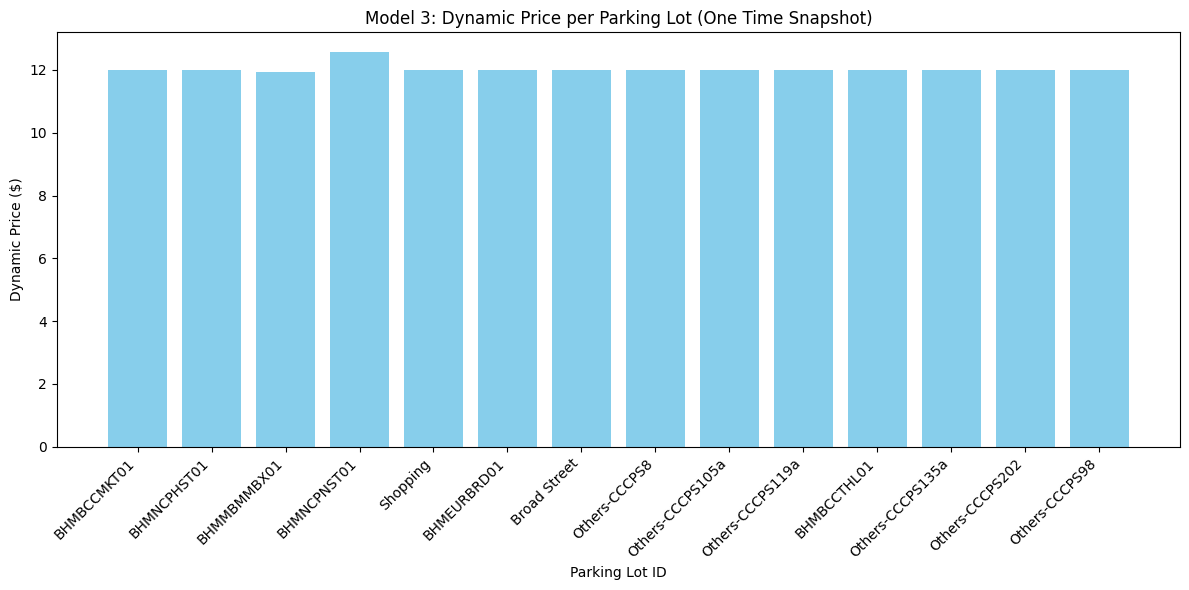

In [70]:
import matplotlib.pyplot as plt

# Increase figure size for better visibility
plt.figure(figsize=(12, 6))

# Plot the bar chart
plt.bar(one_time['LotID'], one_time['DynamicPrice'], color='skyblue')

# Labeling
plt.xlabel("Parking Lot ID")
plt.ylabel("Dynamic Price ($)")
plt.title("Model 3: Dynamic Price per Parking Lot (One Time Snapshot)")
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for clarity
plt.tight_layout()

# Display the plot
plt.show()


In [71]:
print(one_time[['LotID', 'DynamicPrice']].head(10))


                  LotID  DynamicPrice
0           BHMBCCMKT01     12.000000
5248        BHMNCPHST01     12.000000
3936        BHMMBMMBX01     11.921397
6560        BHMNCPNST01     12.567010
17056          Shopping     12.000000
2624        BHMEURBRD01     12.000000
7872       Broad Street     12.000000
14432     Others-CCCPS8     12.000000
9184   Others-CCCPS105a     12.000000
10496  Others-CCCPS119a     12.000000


In [72]:
print(df['LotID'].unique()[:10])  # Just checking first 10


['BHMBCCMKT01' 'BHMNCPHST01' 'BHMMBMMBX01' 'BHMNCPNST01' 'Shopping'
 'BHMEURBRD01' 'Broad Street' 'Others-CCCPS8' 'Others-CCCPS105a'
 'Others-CCCPS119a']


In [73]:
print(one_time.shape)


(14, 7)


In [74]:
# Filter only the first timestamp
one_time = df[df['Timestamp'] == df['Timestamp'].min()].copy()


In [75]:
lot_info = one_time[['LotID', 'Occupancy', 'Capacity']].copy()


In [76]:
lot_info['DynamicPrice'] = 10 + (lot_info['Occupancy'] / lot_info['Capacity']) * 10


In [77]:
lot_info['LotID'] = lot_info['LotID'].astype(str)


In [78]:
print(df[['LotID', 'Timestamp']].head())


             LotID           Timestamp
0      BHMBCCMKT01 2016-10-04 07:59:00
5248   BHMNCPHST01 2016-10-04 07:59:00
3936   BHMMBMMBX01 2016-10-04 07:59:00
6560   BHMNCPNST01 2016-10-04 07:59:00
17056     Shopping 2016-10-04 07:59:00


In [79]:
# Base price and simple dynamic adjustment
base_price = 10
df_model3['DynamicPrice'] = base_price + (df_model3['Occupancy'] / df_model3['Capacity']) * 10


/tmp/ipython-input-79-3213340012.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model3['DynamicPrice'] = base_price + (df_model3['Occupancy'] / df_model3['Capacity']) * 10


In [80]:
lot_info = df_model3[['LotID', 'Latitude', 'Longitude', 'Occupancy', 'Capacity', 'DynamicPrice']].copy()


In [81]:
import numpy as np

# Convert latitude and longitude to radians
lat = np.radians(lot_info['Latitude'].values)
lon = np.radians(lot_info['Longitude'].values)
prices = lot_info['DynamicPrice'].values
lot_ids = lot_info['LotID'].values

avg_comp_prices = []

# Haversine fast calculation (vectorized)
for i in range(len(lot_ids)):
    lat1 = lat[i]
    lon1 = lon[i]

    dlat = lat - lat1
    dlon = lon - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    distance_km = 6371 * c  # Radius of Earth in KM

    # Exclude self and filter nearby (<= 1 km)
    mask = (distance_km <= 1) & (distance_km > 0)
    nearby_prices = prices[mask]

    avg_price = np.mean(nearby_prices) if len(nearby_prices) > 0 else None
    avg_comp_prices.append(avg_price)

# Add to DataFrame
lot_info['AvgCompetitorPrice'] = avg_comp_prices


In [82]:
def suggest_adjustment(row):
    if row['Occupancy'] / row['Capacity'] > 0.9:
        if row['AvgCompetitorPrice'] is not None and row['AvgCompetitorPrice'] < row['DynamicPrice']:
            return "Suggest rerouting"
    return "OK"

lot_info['Suggestion'] = lot_info.apply(suggest_adjustment, axis=1)


In [83]:
print(lot_info[['LotID', 'DynamicPrice', 'AvgCompetitorPrice', 'Suggestion']])


                LotID  DynamicPrice  AvgCompetitorPrice         Suggestion
0         BHMBCCMKT01     11.057192           15.126737                 OK
5248      BHMNCPHST01     11.975000           14.596384                 OK
3936      BHMMBMMBX01     13.842795                 NaN                 OK
6560      BHMNCPNST01     15.134021           14.457690                 OK
17056        Shopping     13.197917           14.656427                 OK
...               ...           ...                 ...                ...
3935      BHMEURBRD01     17.936170           15.272069                 OK
2623      BHMBCCTHL01     20.000000           14.739824  Suggest rerouting
1311      BHMBCCMKT01     13.344887           15.126737                 OK
17055  Others-CCCPS98     15.385111           14.829995                 OK
18367        Shopping     16.145833           14.656427                 OK

[18368 rows x 4 columns]


In [84]:
lot_info.to_csv("model3_output.csv", index=False)


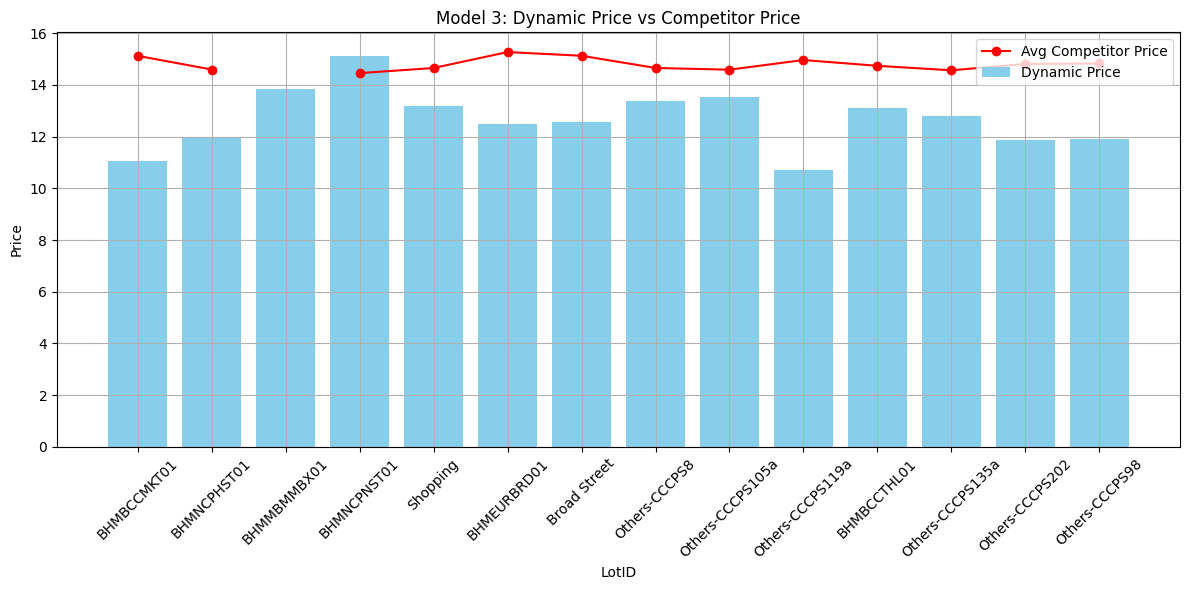

In [101]:
import matplotlib.pyplot as plt

sample = lot_info.head(14)  # pick one timestamp snapshot

plt.figure(figsize=(12,6))
plt.bar(sample['LotID'].astype(str), sample['DynamicPrice'], color='skyblue', label='Dynamic Price')
plt.plot(sample['LotID'].astype(str), sample['AvgCompetitorPrice'], color='red', marker='o', label='Avg Competitor Price')
plt.xlabel("LotID")
plt.ylabel("Price")
plt.title("Model 3: Dynamic Price vs Competitor Price")
plt.legend()
plt.grid()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [86]:
lot_info.to_csv("final_model3_output.csv", index=False)


In [87]:
print(df_model3['Timestamp'].dtype)


datetime64[ns]


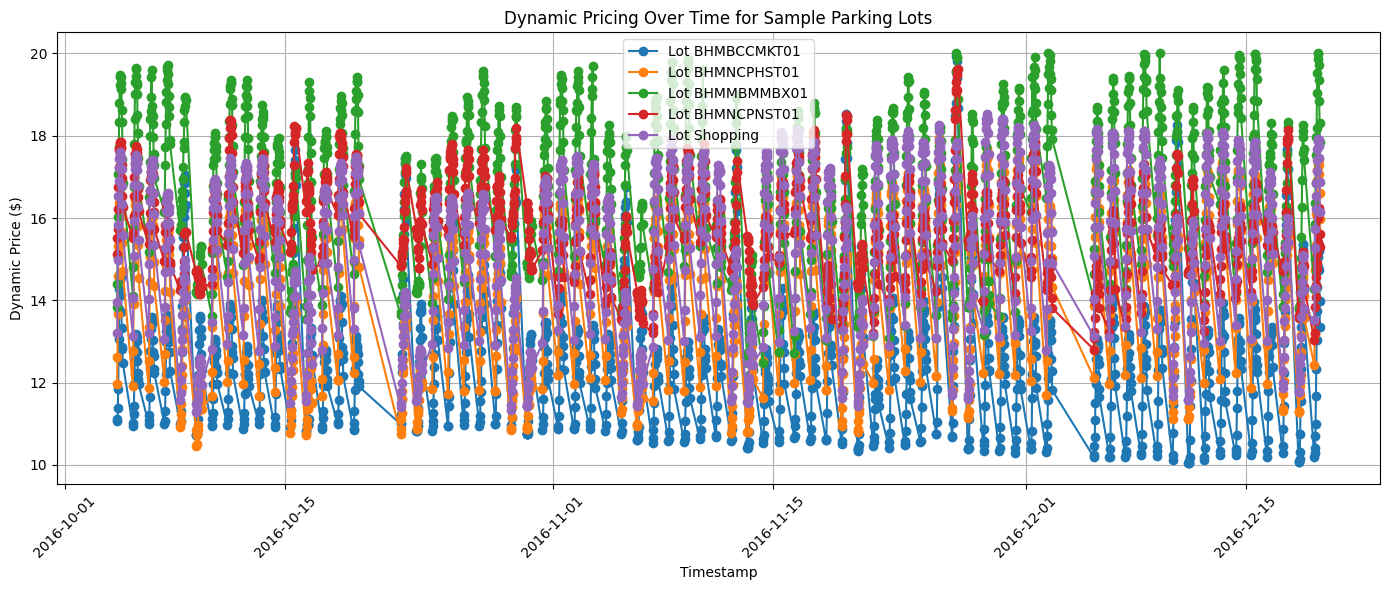

In [88]:
import matplotlib.pyplot as plt

# Pick 5 LotIDs to visualize
sample_lots = df_model3['LotID'].unique()[:5]

plt.figure(figsize=(14, 6))

for lot in sample_lots:
    lot_data = df_model3[df_model3['LotID'] == lot].sort_values('Timestamp')

    # Only plot if there are multiple timestamps
    if len(lot_data) > 1:
        plt.plot(lot_data['Timestamp'], lot_data['DynamicPrice'], label=f"Lot {lot}", marker='o')
    elif len(lot_data) == 1:
        plt.scatter(lot_data['Timestamp'], lot_data['DynamicPrice'], label=f"Lot {lot} (single point)")

plt.title("Dynamic Pricing Over Time for Sample Parking Lots")
plt.xlabel("Timestamp")
plt.ylabel("Dynamic Price ($)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [89]:
print(df_model3.columns)


Index(['LotID', 'Timestamp', 'Latitude', 'Longitude', 'Occupancy', 'Capacity',
       'DynamicPrice'],
      dtype='object')


In [90]:
print(df['LotID'].unique())


['BHMBCCMKT01' 'BHMNCPHST01' 'BHMMBMMBX01' 'BHMNCPNST01' 'Shopping'
 'BHMEURBRD01' 'Broad Street' 'Others-CCCPS8' 'Others-CCCPS105a'
 'Others-CCCPS119a' 'BHMBCCTHL01' 'Others-CCCPS135a' 'Others-CCCPS202'
 'Others-CCCPS98']


/tmp/ipython-input-91-1241671194.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model3['Hour'] = df_model3['Timestamp'].dt.hour


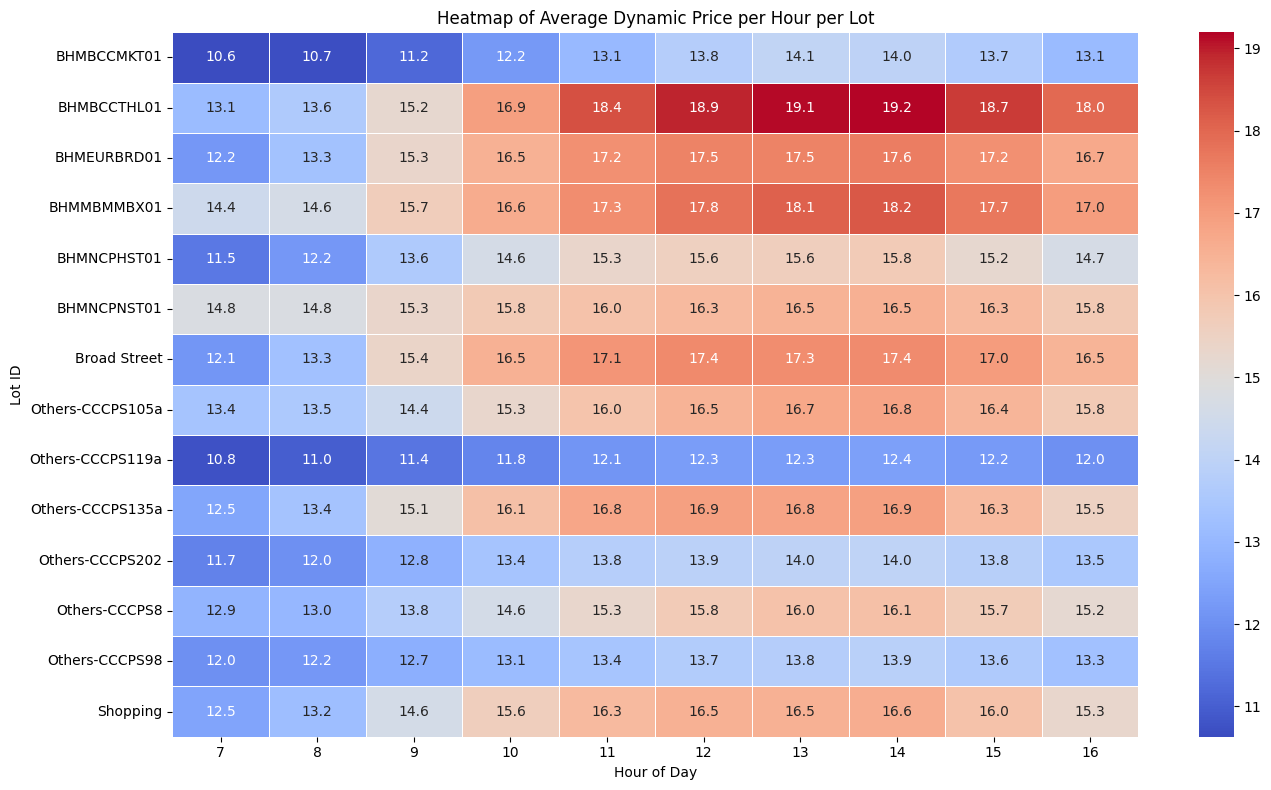

In [91]:
import seaborn as sns
import matplotlib.pyplot as plt

# Make sure Timestamp is datetime
df_model3['Hour'] = df_model3['Timestamp'].dt.hour

# Create pivot table: LotID (rows) vs Hour (columns)
pivot_table = df_model3.pivot_table(
    index='LotID',
    columns='Hour',
    values='DynamicPrice',
    aggfunc='mean'
)

# Plot heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(pivot_table, cmap='coolwarm', annot=True, fmt=".1f", linewidths=0.5)
plt.title("Heatmap of Average Dynamic Price per Hour per Lot")
plt.xlabel("Hour of Day")
plt.ylabel("Lot ID")
plt.tight_layout()
# 🔽 Save the figure
plt.savefig("dynamic_price_heatmap.png", dpi=300)
plt.show()


In [92]:
print(one_time.columns)


Index(['ID', 'LotID', 'Capacity', 'Latitude', 'Longitude', 'Occupancy',
       'VehicleType', 'TrafficConditionNearby', 'QueueLength', 'IsSpecialDay',
       'LastUpdatedDate', 'LastUpdatedTime', 'TrafficNum', 'VehicleTypeWeight',
       'Demand', 'NormalizedDemand', 'Price', 'Timestamp'],
      dtype='object')


In [93]:
def compute_dynamic_price(current_lot, df_all, base_price=10):
    df_all = df_all.copy()
    df_all['Distance'] = df_all.apply(
        lambda row: haversine(current_lot['Latitude'], current_lot['Longitude'],
                              row['Latitude'], row['Longitude']), axis=1)

    nearby = df_all[(df_all['Distance'] < 1) & (df_all['LotID'] != current_lot['LotID'])]

    nearby['price'] = 10 + (nearby['Occupancy'] / nearby['Capacity']) * 10
    avg_price = nearby['price'].mean() if not nearby.empty else base_price

    occ_ratio = current_lot['Occupancy'] / current_lot['Capacity']

    if occ_ratio > 0.9 and avg_price < base_price:
        return max(base_price - 2, 5)
    elif occ_ratio < 0.4 and avg_price > base_price:
        return min(base_price + 2, 20)
    else:
        return base_price + occ_ratio * 5


In [94]:
one_time['DynamicPrice'] = one_time.apply(lambda row: compute_dynamic_price(row, one_time), axis=1)


/tmp/ipython-input-95-2179838565.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model3['OccupancyRatio'] = df_model3['Occupancy'] / df_model3['Capacity']


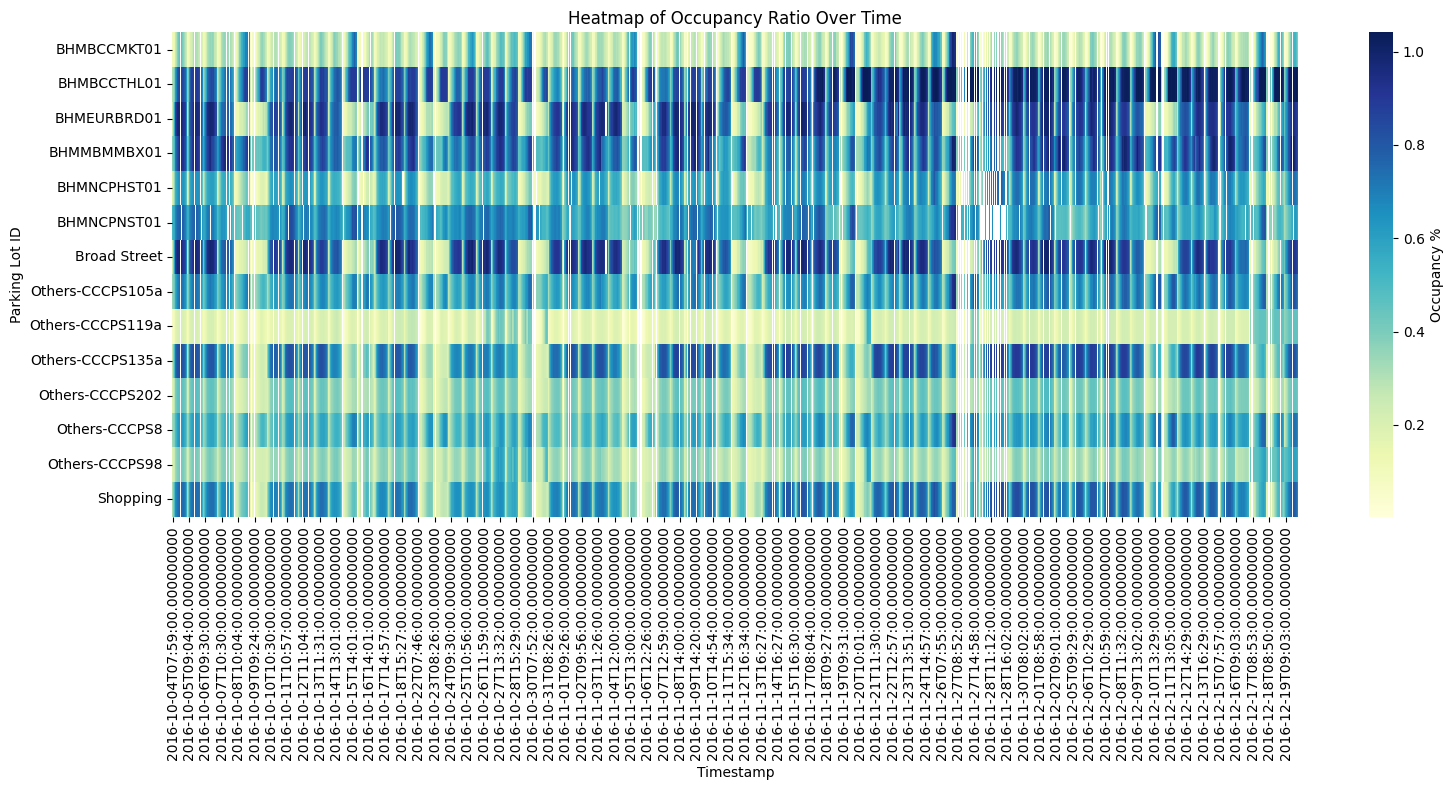

In [95]:
import seaborn as sns

# Create occupancy ratio
df_model3['OccupancyRatio'] = df_model3['Occupancy'] / df_model3['Capacity']

# Pivot the data: rows = timestamp, columns = LotID, values = OccupancyRatio
heatmap_data = df_model3.pivot_table(index='Timestamp', columns='LotID', values='OccupancyRatio')

# Plot heatmap
plt.figure(figsize=(16, 8))
sns.heatmap(heatmap_data.transpose(), cmap="YlGnBu", cbar_kws={'label': 'Occupancy %'})
plt.title("Heatmap of Occupancy Ratio Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Parking Lot ID")
plt.tight_layout()
plt.show()


/tmp/ipython-input-96-3843393028.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model3['Date'] = pd.to_datetime(df_model3['Timestamp']).dt.date


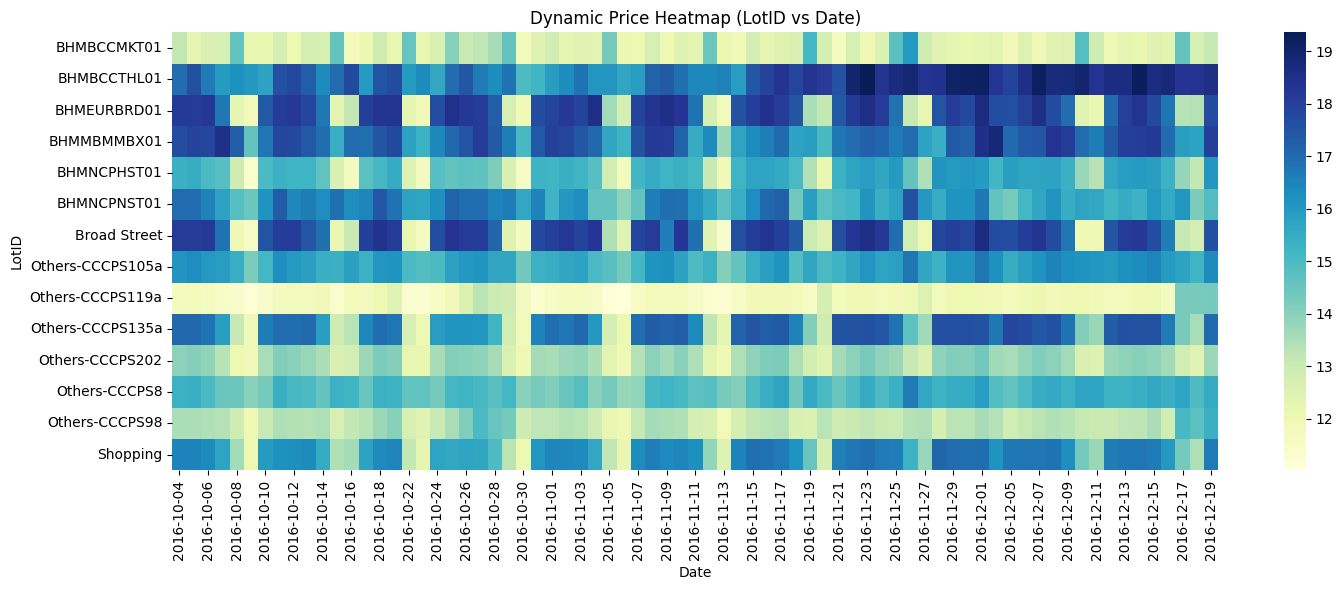

In [96]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Convert Timestamp to Date
df_model3['Date'] = pd.to_datetime(df_model3['Timestamp']).dt.date

# Step 2: Create Pivot Table
heatmap_data = df_model3.pivot_table(
    index='LotID',
    columns='Date',
    values='DynamicPrice'
)

# Step 3: Plot Heatmap
plt.figure(figsize=(15, 6))
sns.heatmap(heatmap_data, cmap="YlGnBu", annot=False)
plt.title("Dynamic Price Heatmap (LotID vs Date)")
plt.xlabel("Date")
plt.ylabel("LotID")
plt.tight_layout()
plt.show()


In [97]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])


df['Date'] = df['Timestamp'].dt.date


grouped = df.groupby(['LotID', 'Date']).agg({
    'Occupancy': ['max', 'min'],
    'Capacity': 'max'
}).reset_index()


grouped.columns = ['LotID', 'Date', 'occ_max', 'occ_min', 'cap']

grouped['DynamicPrice'] = 10 + (grouped['occ_max'] - grouped['occ_min']) / grouped['cap']


print(grouped.head())


         LotID        Date  occ_max  occ_min  cap  DynamicPrice
0  BHMBCCMKT01  2016-10-04      269       61  577     10.360485
1  BHMBCCMKT01  2016-10-05      183       54  577     10.223570
2  BHMBCCMKT01  2016-10-06      208       58  577     10.259965
3  BHMBCCMKT01  2016-10-07      210       58  577     10.263432
4  BHMBCCMKT01  2016-10-08      406       58  577     10.603120


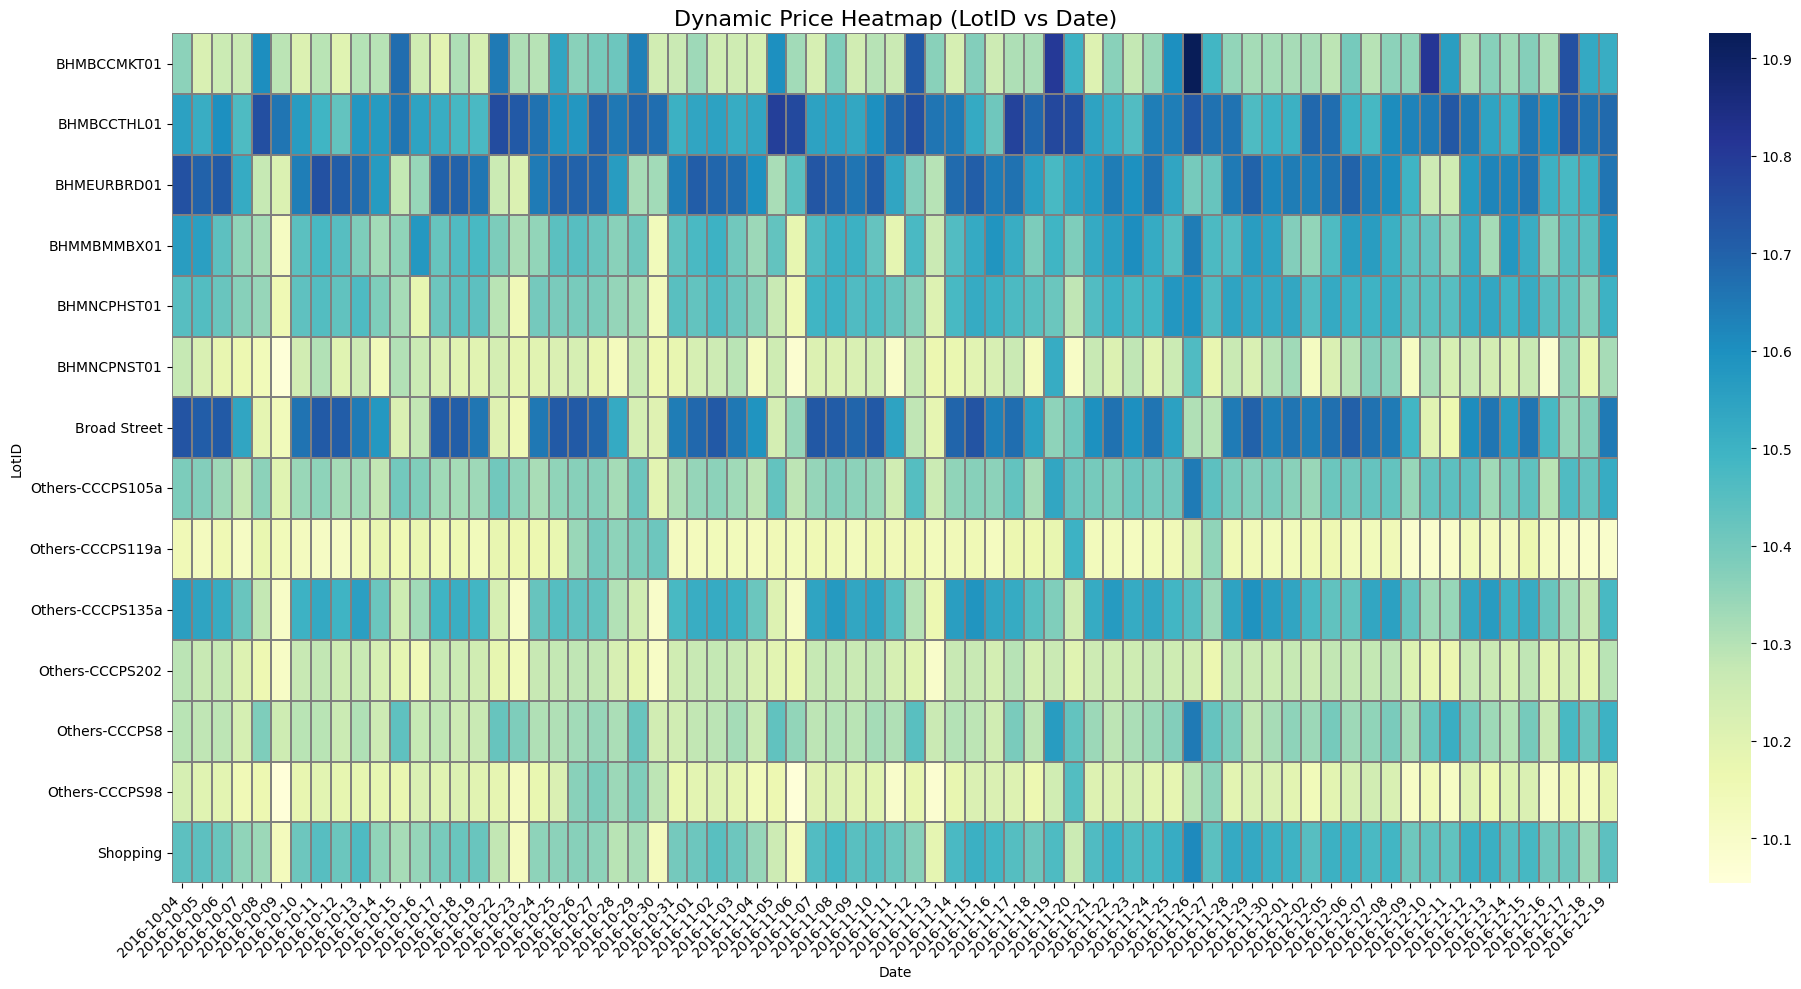

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pivot the table to get LotID as rows and Date as columns
heatmap_data = grouped.pivot(index='LotID', columns='Date', values='DynamicPrice')

# Set figure size
plt.figure(figsize=(20, 10))

# Create heatmap
sns.heatmap(heatmap_data, cmap='YlGnBu', linewidths=0.2, linecolor='gray')

# Add labels and title
plt.title('Dynamic Price Heatmap (LotID vs Date)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('LotID')

# Rotate x-axis labels
plt.xticks(rotation=45, ha='right')

# Show plot
plt.tight_layout()
plt.show()


In [108]:
# Model 1: Baseline Linear Model
one_time['BaselinePrice'] = 10 + (one_time['Occupancy'] / one_time['Capacity']) * 5

# Model 2: Demand-Based

if 'DemandPrice' not in one_time.columns:
    one_time['DemandPrice'] = 10 + (one_time['Occupancy'] / one_time['Capacity']) * 7  # simplified

# Model 3



In [109]:
print(one_time[['LotID', 'BaselinePrice', 'DemandPrice', 'DynamicPrice']].head())


             LotID  BaselinePrice  DemandPrice  DynamicPrice
0      BHMBCCMKT01      10.528596    10.740035     12.000000
5248   BHMNCPHST01      10.987500    11.382500     12.000000
3936   BHMMBMMBX01      11.921397    12.689956     11.921397
6560   BHMNCPNST01      12.567010    13.593814     12.567010
17056     Shopping      11.598958    12.238542     12.000000


In [110]:
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource
from bokeh.transform import dodge
from bokeh.palettes import Category10
import panel as pn

pn.extension()

# Ensure LotID is string
one_time['LotID'] = one_time['LotID'].astype(str)

# Create ColumnDataSource
source = ColumnDataSource(one_time)

# Create the figure
p = figure(
    x_range=one_time['LotID'].tolist(),
    height=450,
    width=1000,
    title="Comparison of Parking Prices: Model 1, 2, 3",
    toolbar_location=None,
    tools=""
)

# Add vbars for each model with dodge to separate
p.vbar(x=dodge('LotID', -0.25, range=p.x_range), top='BaselinePrice', width=0.2, source=source,
       color=Category10[3][0], legend_label="Model 1: Baseline")

p.vbar(x=dodge('LotID',  0.00, range=p.x_range), top='DemandPrice', width=0.2, source=source,
       color=Category10[3][1], legend_label="Model 2: Demand-Based")

p.vbar(x=dodge('LotID',  0.25, range=p.x_range), top='DynamicPrice', width=0.2, source=source,
       color=Category10[3][2], legend_label="Model 3: Dynamic")

# Aesthetic improvements
p.xaxis.major_label_orientation = 1.2
p.xaxis.axis_label = "Parking Lot ID"
p.yaxis.axis_label = "Price"
p.legend.location = "top_left"
p.legend.click_policy = "hide"

# Show using Panel
pn.Column(p).servable()


Column
    [0] Bokeh(figure)

In [112]:
df_combined = pd.DataFrame({
    "LotID": one_time['LotID'],
    "BaselinePrice": one_time['BaselinePrice'],     # Model 1
    "DemandPrice": one_time['DemandPrice'],         # Model 2
    "DynamicPrice": one_time['DynamicPrice']        # Model 3
})


In [115]:
from bokeh.plotting import figure, show, output_file, save
from bokeh.models import ColumnDataSource
from bokeh.transform import dodge
from bokeh.palettes import Category10
import pandas as pd

# Assume df_combined is already defined with LotID, BaselinePrice, DemandPrice, DynamicPrice

source = ColumnDataSource(df_combined)

p = figure(x_range=source.data['LotID'], height=400, width=900,
           title="Comparison of Parking Prices: Model 1 vs Model 2 vs Model 3",
           toolbar_location=None, tools="")

p.vbar(x=dodge('LotID', -0.25, range=p.x_range), top='BaselinePrice', width=0.2,
       source=source, color=Category10[3][0], legend_label="Model 1: Baseline")

p.vbar(x=dodge('LotID', 0.0, range=p.x_range), top='DemandPrice', width=0.2,
       source=source, color=Category10[3][1], legend_label="Model 2: Demand-Based")

p.vbar(x=dodge('LotID', 0.25, range=p.x_range), top='DynamicPrice', width=0.2,
       source=source, color=Category10[3][2], legend_label="Model 3: Dynamic")

p.xgrid.grid_line_color = None
p.y_range.start = 0
p.xaxis.major_label_orientation = 1
p.legend.location = "top_left"
p.legend.orientation = "horizontal"

# ✅ Save as HTML
output_file("model_comparison_plot.html")
save(p)



'/content/model_comparison_plot.html'

In [116]:
from bokeh.io import output_file, save
from bokeh.models import ColumnDataSource
from bokeh.plotting import figure
from bokeh.transform import dodge
from bokeh.palettes import Category10

# Create a new ColumnDataSource
source = ColumnDataSource(df_combined)  # assuming df_combined has LotID, BaselinePrice, DemandPrice, DynamicPrice

# Create a new figure
p = figure(
    x_range=source.data['LotID'],
    height=400,
    width=900,
    title="Comparison of Parking Prices: Model 1 vs Model 2 vs Model 3",
    toolbar_location=None,
    tools=""
)

# Plot bars with dodge to separate them
p.vbar(x=dodge('LotID', -0.25, range=p.x_range), top='BaselinePrice', width=0.2,
       source=source, color=Category10[3][0], legend_label="Model 1: Baseline")

p.vbar(x=dodge('LotID', 0.0, range=p.x_range), top='DemandPrice', width=0.2,
       source=source, color=Category10[3][1], legend_label="Model 2: Demand-Based")

p.vbar(x=dodge('LotID', 0.25, range=p.x_range), top='DynamicPrice', width=0.2,
       source=source, color=Category10[3][2], legend_label="Model 3: Dynamic")

# Styling
p.xgrid.grid_line_color = None
p.y_range.start = 0
p.xaxis.major_label_orientation = 1
p.legend.location = "top_left"
p.legend.orientation = "horizontal"

# Save to HTML
output_file("model_comparison_plot.html")
save(p)


'/content/model_comparison_plot.html'

In [118]:
from bokeh.io import output_file, save
output_file("model_comparison_plot.html")
save(p)


'/content/model_comparison_plot.html'

In [119]:
from IPython.display import HTML

with open("model_comparison_plot.html", "r") as f:
    html_data = f.read()

HTML(html_data)


In [99]:
import pandas as pd
import panel as pn
import bokeh.plotting
from bokeh.models import ColumnDataSource

# Activate the Panel extension
pn.extension()

# ---- Data Setup (assuming you have the grouped DataFrame with 'Date' and 'DynamicPrice') ----

# Rename columns to match the expected keys in the Bokeh figure
grouped = grouped.rename(columns={'Date': 't', 'DynamicPrice': 'price'})

# Create a ColumnDataSource from your Pandas DataFrame
source = ColumnDataSource(grouped)

# ---- Bokeh Plotting Function ----
def price_plotter(source):
    fig = bokeh.plotting.figure(
        height=400,
        width=800,
        title="Daily Parking Price",
        x_axis_type="datetime",
        x_axis_label="Date",
        y_axis_label="Price"
    )

    fig.line("t", "price", source=source, line_width=2, color="navy")
    fig.circle("t", "price", source=source, size=6, color="red")

    return fig

# ---- Create Interactive Plot ----
plot = price_plotter(source)

# ---- Wrap it in a Panel layout and serve ----
app = pn.Column(plot)
app.servable()


Column
    [0] Bokeh(figure)